## Import Libraries

In [ ]:
import os, zipfile, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from collections import Counter
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import img_to_array, plot_model

from skimage.metrics import structural_similarity as ssim

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
!pip install pydot graphviz

## Load Dataset

### Upload and Extract Dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

zip_path = "archive.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset berhasil diekstrak.")

Saving archive.zip to archive.zip
Dataset berhasil diekstrak.


In [ ]:
base_dir = os.path.join(extract_path, "version2")
train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

CLASSES = ["ship", "helicopter"]
IMG_SIZE = (28, 28)

### Load Picture (Ship & Helicopter)

In [ ]:
all_images = []
all_labels = []

for split_name, split_dir in [("train", train_dir), ("test", test_dir)]:
    for label in CLASSES:
        class_folder = os.path.join(split_dir, label)
        image_files  = os.listdir(class_folder)
        print(f"{label} ({split_name}) : {len(image_files)} gambar")

        for file in image_files:
            img_path = os.path.join(class_folder, file)
            image = Image.open(img_path)
            image = image.convert("L")
            image = image.resize(IMG_SIZE)
            image = img_to_array(image)
            all_images.append(image)
            all_labels.append(label)

all_images = np.array(all_images, dtype=np.float32)
all_labels = np.array(all_labels)

print(f"\nTotal seluruh gambar : {all_images.shape}")
print(f"Distribusi kelas     : {dict(Counter(all_labels))}")

ship (train) : 7124 gambar
helicopter (train) : 5250 gambar
ship (test) : 888 gambar
helicopter (test) : 656 gambar

Total seluruh gambar : (13918, 28, 28, 1)
Distribusi kelas     : {np.str_('ship'): 8012, np.str_('helicopter'): 5906}


### Scaling

In [ ]:
all_images = all_images / 255.0

print(f"Pixel min : {all_images.min():.1f}")
print(f"Pixel max : {all_images.max():.1f}")

Pixel min : 0.0
Pixel max : 1.0


### Data Example

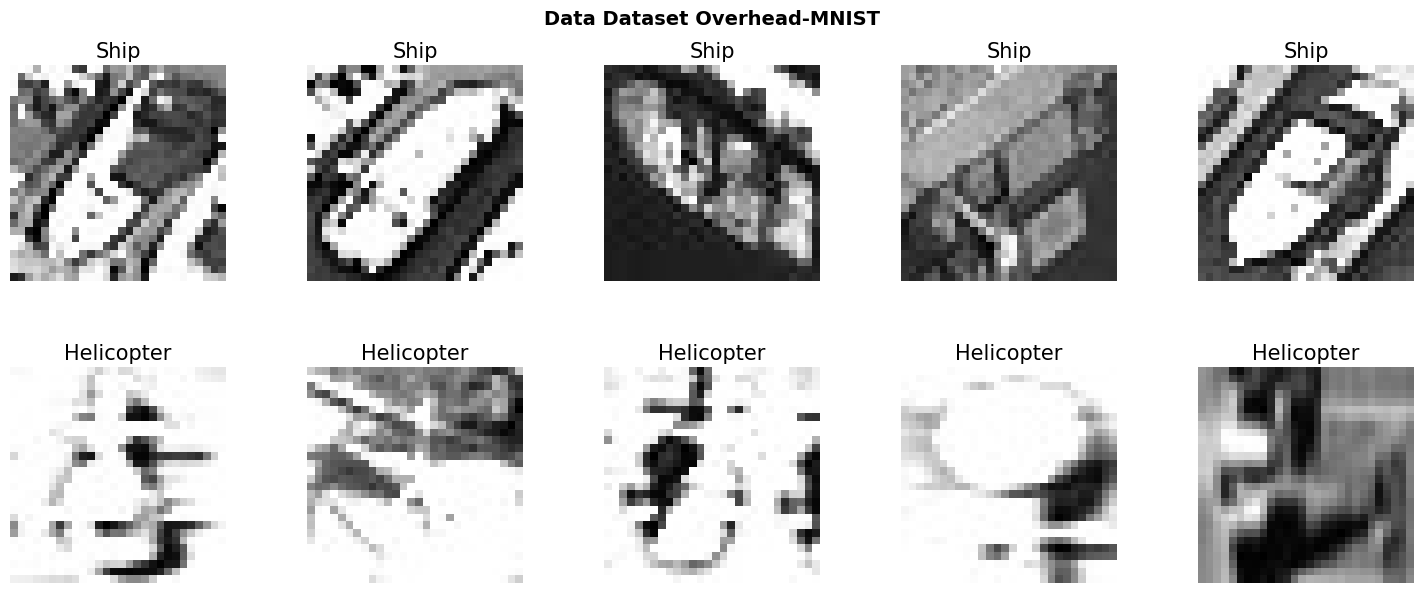

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Data Dataset Overhead-MNIST", fontsize=14, fontweight="bold")

for row_idx, cls in enumerate(CLASSES):
    idx_list = np.where(all_labels == cls)[0][:5]

    for col_idx, img_idx in enumerate(idx_list):
        ax = axes[row_idx, col_idx]
        ax.imshow(all_images[img_idx].squeeze(), cmap="gray")
        ax.set_title(cls.capitalize(), fontsize=15, pad=5)
        ax.axis("off")

plt.tight_layout()
plt.subplots_adjust(hspace=0.4)
plt.show()

## Splitting Data

In [ ]:
x_trainval, x_test, y_trainval, y_test = train_test_split(all_images, all_labels, test_size=0.10, random_state=SEED, stratify=all_labels)
x_train, x_val, y_train, y_val = train_test_split(x_trainval, y_trainval, test_size=(1/9), random_state=SEED, stratify=y_trainval)

N = len(all_images)
print("Training Set   :", x_train.shape, f"  ({len(x_train)/N*100:.1f}%)")
print("Validation Set :", x_val.shape,   f"  ({len(x_val)/N*100:.1f}%)")
print("Testing Set    :", x_test.shape,  f"  ({len(x_test)/N*100:.1f}%)")

print("\nTraining")
print(Counter(y_train))
print("\nValidation")
print(Counter(y_val))
print("\nTesting")
print(Counter(y_test))

Training Set   : (11134, 28, 28, 1)   (80.0%)
Validation Set : (1392, 28, 28, 1)   (10.0%)
Testing Set    : (1392, 28, 28, 1)   (10.0%)

Training
Counter({np.str_('ship'): 6410, np.str_('helicopter'): 4724})

Validation
Counter({np.str_('ship'): 801, np.str_('helicopter'): 591})

Testing
Counter({np.str_('ship'): 801, np.str_('helicopter'): 591})


## Baseline Autoencoder

In [ ]:
def build_baseline_autoencoder(latent_dim=128):
    encoder_input = keras.Input(shape=(28, 28, 1), name="encoder_input")

    x = layers.Conv2D(filters=32, kernel_size=(3, 3), activation="relu", padding="same", name="encoder_conv")(encoder_input)
    x = layers.MaxPooling2D( pool_size=(2, 2), padding="same", name="encoder_maxpool")(x)
    x = layers.Flatten(name="encoder_flatten")(x)
    latent = layers.Dense(units=latent_dim, activation="relu", name="latent_vector")(x)

    encoder = Model(encoder_input, latent, name="Encoder")

    decoder_input = keras.Input(shape=(latent_dim,), name="decoder_input")
    x = layers.Dense(units=14 * 14 * 32, name="decoder_dense")(decoder_input)
    x = layers.Reshape(target_shape=(14, 14, 32), name="decoder_reshape")(x)
    x = layers.UpSampling2D(size=(2, 2), name="decoder_upsampling")(x)
    x = layers.Conv2D(filters=32, kernel_size=(3, 3), activation="relu", padding="same", name="decoder_conv_relu")(x)

    decoder_output = layers.Conv2D(filters=1, kernel_size=(3, 3), activation="sigmoid", padding="same", name="decoder_output")(x)

    decoder = Model(decoder_input, decoder_output, name="Decoder")

    autoencoder_input = keras.Input(shape=(28, 28, 1), name="autoencoder_input")
    reconstructed = decoder(encoder(autoencoder_input))
    autoencoder = Model(autoencoder_input, reconstructed, name="Baseline_Convolutional_Autoencoder")

    return autoencoder, encoder, decoder

baseline_ae, baseline_encoder, baseline_decoder = build_baseline_autoencoder(latent_dim=128)
baseline_ae.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss="mse")

print('=== ENCODER ===')
baseline_encoder.summary()
print('\n=== DECODER ===')
baseline_decoder.summary()
print('\n=== AUTOENCODER BASELINE ===')
baseline_ae.summary()

=== ENCODER ===


Model: "Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv (Conv2D)           │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_maxpool (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_flatten (Flatten)       │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_vector (Dense)           │ (None, 128)            │       802,944 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 803,264 (3.06 MB)

 Trainable params: 803,264 (3.06 MB)

...

Model: "Baseline_Convolutional_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ autoencoder_input (InputLayer)  │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder (Functional)            │ (None, 128)            │       803,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder (Functional)            │ (None, 28, 28, 1)      │       818,625 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,621,889 (6.19 MB)

 Trainable params: 1,621,889 (6.19 MB)

 Non-trainable params: 0 (0.00 B)

### Training Baseline Autoencoder

In [ ]:
EPOCHS = 50
BATCH_SIZE = 64

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    filepath="baseline_autoencoder.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

history_baseline = baseline_ae.fit(
    x=x_train,
    y=x_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_val, x_val),
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

Epoch 1/50
174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0879
Epoch 1: val_loss improved from None to 0.05339, saving model to baseline_autoencoder.keras

Epoch 1: finished saving model to baseline_autoencoder.keras
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0719 - val_loss: 0.0534
Epoch 2/50
169/174 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0509
Epoch 2: val_loss improved from 0.05339 to 0.04516, saving model to baseline_autoencoder.keras

Epoch 2: finished saving model to baseline_autoencoder.keras
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0486 - val_loss: 0.0452
Epoch 3/50
173/174 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0444
Epoch 3: val_loss improved from 0.04516 to 0.04188, saving model to baseline_autoencoder.keras

Epoch 3: finished saving model to baseline_autoencoder.keras
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0434 - val_loss: 0.0419
Epoch 4/50
167/174 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0416
Epoch 4: val_loss improved from 0.041

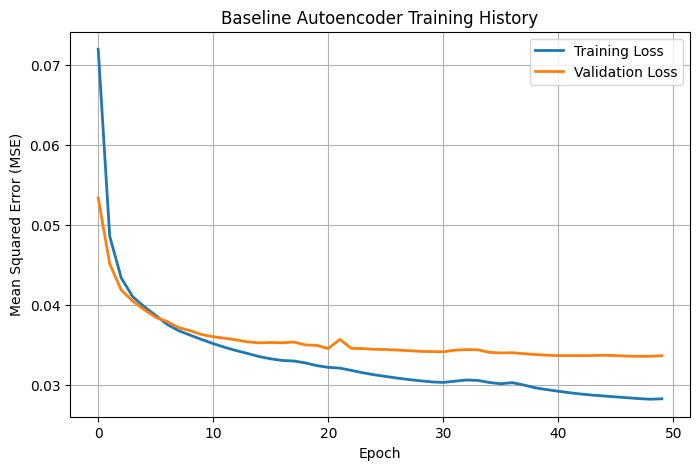

In [ ]:
def plot_training_history(history, model_name):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Training Loss", linewidth=2)
    plt.plot(history.history["val_loss"], label="Validation Loss", linewidth=2)
    plt.title(f"{model_name} Training History")
    plt.xlabel("Epoch")
    plt.ylabel("Mean Squared Error (MSE)")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_training_history(history_baseline, "Baseline Autoencoder")

### Baseline Reconstruction Results

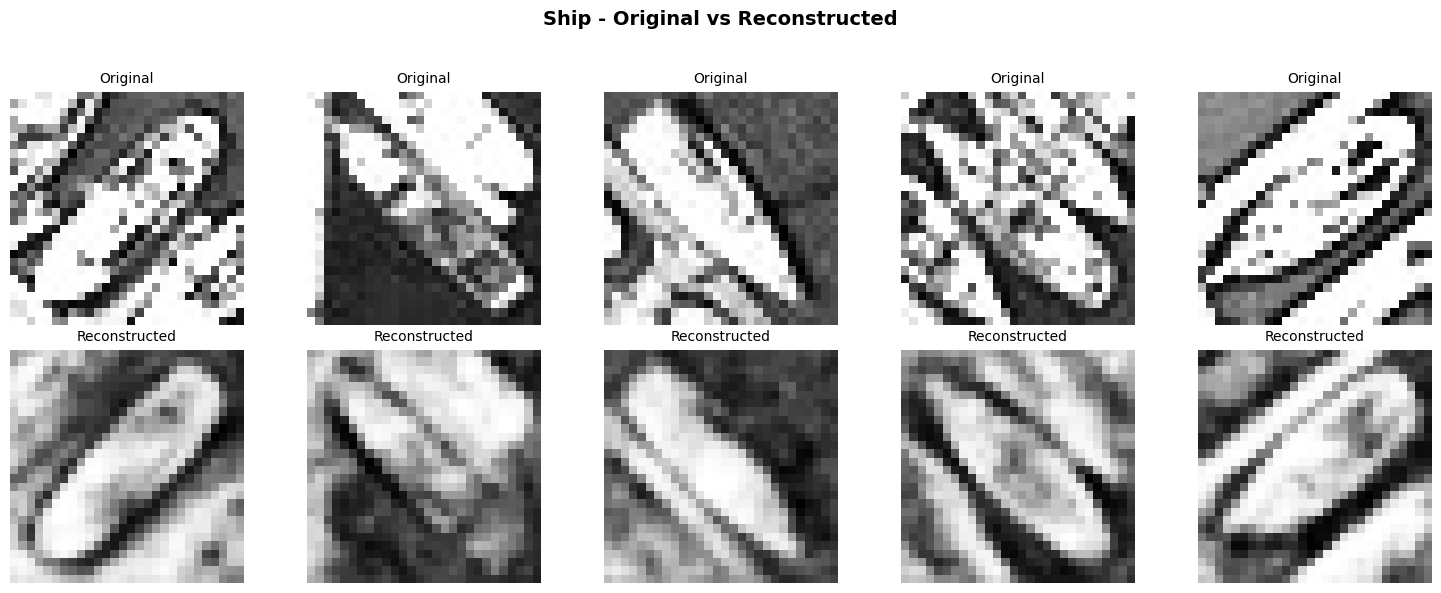

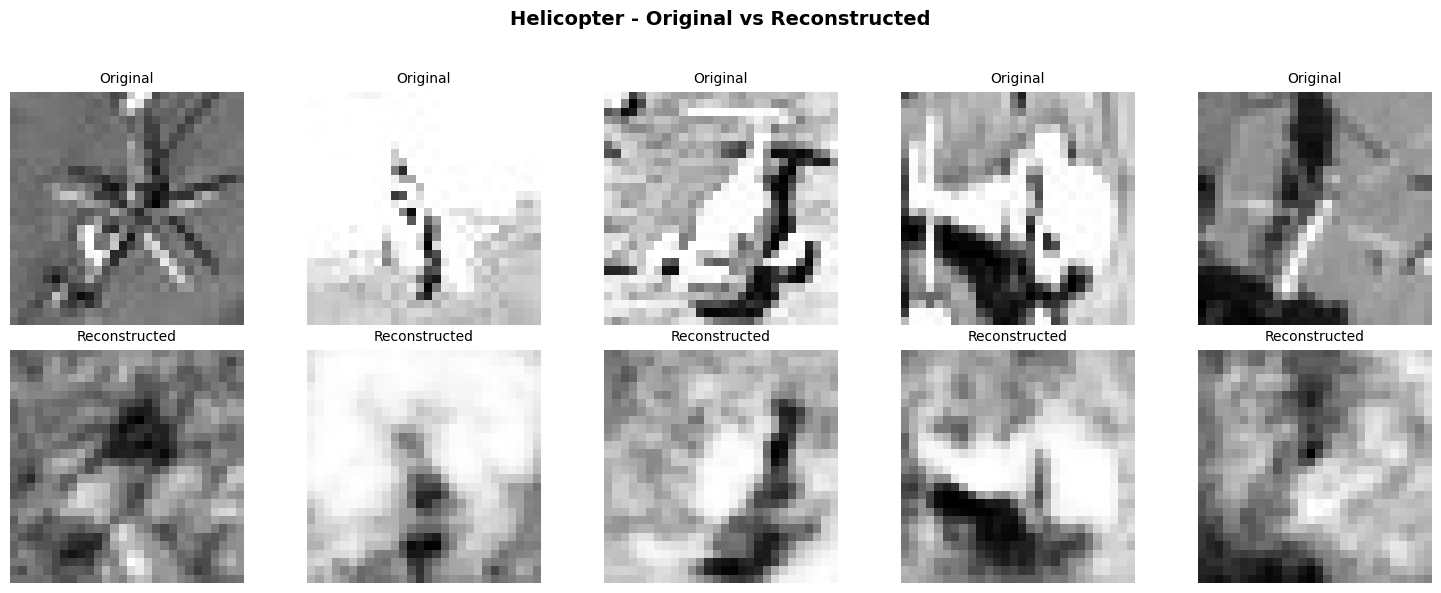

In [ ]:
def visualize_reconstruction(model, x_test, y_test, class_name, n_images=5):
    reconstructed = model.predict(x_test, verbose=0)
    idx_list = np.where(y_test == class_name)[0][:n_images]
    fig, axes = plt.subplots(2, n_images, figsize=(15, 6))
    fig.suptitle(f"{class_name.capitalize()} - Original vs Reconstructed", fontsize=14, fontweight="bold")

    for i, idx in enumerate(idx_list):
        axes[0, i].imshow(x_test[idx].squeeze(), cmap="gray")
        axes[0, i].set_title("Original", fontsize=10)
        axes[0, i].axis("off")

        axes[1, i].imshow(reconstructed[idx].squeeze(), cmap="gray")
        axes[1, i].set_title("Reconstructed", fontsize=10)
        axes[1, i].axis("off")

    axes[0, 0].set_ylabel("Original", fontsize=11, fontweight="bold")
    axes[1, 0].set_ylabel("Reconstructed", fontsize=11, fontweight="bold")

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

visualize_reconstruction(baseline_ae, x_test, y_test, class_name="ship")
visualize_reconstruction(baseline_ae, x_test, y_test, class_name="helicopter")

### SSIM Evaluation

In [ ]:
def evaluate_ssim(model, x_test):
    reconstructed = model.predict(x_test, verbose=0)
    scores = []

    for original, recon in zip(x_test, reconstructed):
        score = ssim(original.squeeze(), recon.squeeze(), data_range=1.0)
        scores.append(score)

    scores = np.array(scores)

    print("SSIM Evaluation")
    print("-"*40)
    print(f"Mean SSIM : {scores.mean():.4f}")
    print(f"Min SSIM  : {scores.min():.4f}")
    print(f"Max SSIM  : {scores.max():.4f}")
    print(f"Std SSIM  : {scores.std():.4f}")

    return scores.mean(), scores

baseline_ssim, baseline_scores = evaluate_ssim(baseline_ae, x_test)

SSIM Evaluation
----------------------------------------
Mean SSIM : 0.5883
Min SSIM  : 0.1348
Max SSIM  : 0.9571
Std SSIM  : 0.1379


Berdasarkan hasil evaluasi, Baseline Autoencoder memperoleh Mean SSIM sebesar 0.5883, yang menunjukkan bahwa **model telah mampu merekonstruksi citra dengan tingkat kemiripan struktur yang cukup baik** terhadap citra asli. Nilai Max SSIM sebesar 0.9571 menunjukkan bahwa beberapa citra dapat direkonstruksi dengan sangat baik, sedangkan Min SSIM sebesar 0.1348 mengindikasikan masih terdapat sampel yang sulit direkonstruksi. Selain itu, Std SSIM sebesar 0.1379 menunjukkan bahwa kualitas rekonstruksi masih cukup bervariasi pada data uji. Hal ini menunjukkan bahwa arsitektur dasar Autoencoder sudah mampu mempelajari representasi fitur untuk rekonstruksi citra, namun karena masih menggunakan arsitektur yang relatif sederhana, kemampuan model dalam mempertahankan informasi spasial dan detail citra masih terbatas sehingga digunakan sebagai model baseline untuk dibandingkan dengan arsitektur hasil modifikasi.

## Modified Autoencoder

### Autoencoder Architecture Modification

- **Batch Normalization**   
Ditambahkan setelah setiap convolution layer dan dense layer untuk menstabilkan distribusi aktivasi selama proses training. Hal ini mempercepat konvergensi model serta meningkatkan stabilitas pembelajaran.
- **He Normal Initialization**   
Digunakan sebagai metode inisialisasi bobot karena sesuai dengan fungsi aktivasi ReLU. Inisialisasi ini membantu menjaga distribusi bobot pada awal pelatihan sehingga proses optimasi menjadi lebih efektif.
- **L2 Regularization (1×10⁻⁵)**   
Diterapkan untuk memberikan penalti pada bobot yang terlalu besar sehingga membantu mengurangi risiko overfitting dan meningkatkan kemampuan generalisasi model.
- **Latent dimension ditingkatkan menjadi 192**   
Karena memberikan keseimbangan yang lebih baik antara tingkat kompresi dan informasi yang dipertahankan. Berdasarkan hasil eksperimen, konfigurasi ini menghasilkan kualitas rekonstruksi yang lebih baik dibandingkan latent dimension yang lebih kecil.
- **Decoder dimodifikasi menggunakan Conv2DTranspose**   
Untuk menggantikan kombinasi UpSampling2D dan Conv2D. Conv2DTranspose melakukan learned upsampling, sehingga model dapat mempelajari proses pembesaran feature map secara langsung dan menghasilkan rekonstruksi citra yang lebih akurat.

In [ ]:
def build_modified_autoencoder(latent_dim=192):
    initializer = "he_normal"
    l2_reg = regularizers.l2(1e-5)

    encoder_input = keras.Input(shape=(28, 28, 1), name="encoder_input")

    x = layers.Conv2D(32, (3,3), padding="same", kernel_initializer=initializer, kernel_regularizer=l2_reg, name="enc_conv1")(encoder_input)
    x = layers.BatchNormalization(name="enc_bn1")(x)
    x = layers.Activation("relu", name="enc_relu1")(x)
    x = layers.MaxPooling2D((2,2), name="enc_pool1")(x)
    x = layers.Conv2D(64, (3,3), padding="same", kernel_initializer=initializer, kernel_regularizer=l2_reg, name="enc_conv2")(x)
    x = layers.BatchNormalization(name="enc_bn2")(x)
    x = layers.Activation("relu", name="enc_relu2")(x)
    x = layers.MaxPooling2D((2,2), name="enc_pool2")(x)
    x = layers.Flatten(name="enc_flatten")(x)
    x = layers.Dense(256, kernel_initializer=initializer, kernel_regularizer=l2_reg, name="enc_dense_transition")(x)
    x = layers.BatchNormalization(name="enc_bn3")(x)
    x = layers.Activation("relu", name="enc_relu3")(x)
    latent = layers.Dense(latent_dim, activation="relu", kernel_initializer=initializer, kernel_regularizer=l2_reg, name="latent_vector")(x)
    encoder_mod = Model(encoder_input, latent, name="Encoder_Modified")

    decoder_input = keras.Input(shape=(latent_dim,), name="decoder_input")

    x = layers.Dense(7 * 7 * 64, kernel_initializer=initializer, kernel_regularizer=l2_reg, name="dec_dense")(decoder_input)
    x = layers.Activation("relu", name="dec_relu1")(x)
    x = layers.Reshape((7,7,64), name="dec_reshape")(x)
    x = layers.Conv2DTranspose(64,(3,3), strides=2, padding="same", activation="relu", kernel_initializer=initializer, kernel_regularizer=l2_reg, name="dec_convtranspose1")(x)
    x = layers.Conv2DTranspose(32,(3,3), strides=2, padding="same", activation="relu", kernel_initializer=initializer, kernel_regularizer=l2_reg, name="dec_convtranspose2")(x)

    decoder_output = layers.Conv2D(1,(3,3), padding="same", activation="sigmoid", name="decoder_output")(x)
    decoder_mod = Model(decoder_input, decoder_output, name="Decoder_Modified")

    ae_input = keras.Input(shape=(28,28,1), name="autoencoder_input")
    ae_output = decoder_mod(encoder_mod(ae_input))
    autoencoder_mod = Model(ae_input, ae_output, name="Modified_Convolutional_Autoencoder")

    return autoencoder_mod, encoder_mod, decoder_mod

modified_ae, modified_encoder, modified_decoder = build_modified_autoencoder(latent_dim=192)

print("=== ENCODER MODIFIED ===")
modified_encoder.summary()
print("\n=== DECODER MODIFIED ===")
modified_decoder.summary()
print("\n=== AUTOENCODER MODIFIED ===")
modified_ae.summary()

=== ENCODER MODIFIED ===


Model: "Encoder_Modified"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv1 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn1 (BatchNormalization)    │ (None, 28, 28, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_relu1 (Activation)          │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool1 (MaxPooling2D)        │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv2 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn2 (BatchNormalization)    │ (None, 14, 14, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_relu2 (Activation)          │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool2 (MaxPooling2D)        │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_flatten (Flatten)           │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense_transition (Dense)    │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn3 (BatchNormalization)    │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_relu3 (Activation)          │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_vector (Dense)           │ (None, 192)            │        49,344 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 872,640 (3.33 MB)

 Trainable params: 871,936 (3.33 MB)

...

Model: "Modified_Convolutional_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ autoencoder_input (InputLayer)  │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_Modified (Functional)   │ (None, 192)            │       872,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_Modified (Functional)   │ (None, 28, 28, 1)      │       660,929 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,533,569 (5.85 MB)

 Trainable params: 1,532,865 (5.85 MB)

 Non-trainable params: 704 (2.75 KB)

Modifikasi arsitektur  membuat proses pembelajaran menjadi lebih stabil, mengurangi risiko overfitting, serta memungkinkan decoder melakukan learned upsampling, sehingga proses rekonstruksi citra menjadi lebih akurat. Selain itu, latent dimension sebesar 192 memberikan keseimbangan yang lebih baik antara kompresi data dan informasi yang dipertahankan.

### Hyperparameter Tuning

- **Adam Optimizer**   
Dipilih karena mampu menyesuaikan
learning rate setiap parameter secara adaptif sehingga proses optimasi menjadi lebih cepat dan stabil.
- **Learning rate sebesar 3×10⁻⁴**   
Dipilih berdasarkan hasil eksperimen karena menghasilkan proses pembelajaran yang lebih stabil dibandingkan learning rate yang lebih besar, sehingga model lebih mudah mencapai konvergensi.
- **Huber Loss**   
Digunakan sebagai fungsi loss karena menggabungkan kelebihan MSE dan MAE, sehingga lebih robust terhadap error rekonstruksi yang besar dan menghasilkan proses training yang lebih stabil.
- **ReduceLROnPlateau**   
Digunakan untuk menurunkan learning rate secara otomatis ketika validation loss mulai stagnan agar proses optimasi dapat mencapai solusi yang lebih baik.
- **EarlyStopping**   
Digunakan untuk menghentikan pelatihan ketika validation loss tidak lagi mengalami peningkatan, sehingga dapat mengurangi overfitting dan menghemat waktu pelatihan.
- **ModelCheckpoint**   
Digunakan untuk menyimpan model dengan validation loss terbaik sehingga model yang digunakan pada tahap evaluasi merupakan model dengan performa terbaik selama proses training.

In [ ]:
modified_ae.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss=keras.losses.Huber(delta=0.1)
)

early_stopping_mod = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_mod = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=7,
    min_lr=1e-6,
    verbose=1
)

model_checkpoint_mod = keras.callbacks.ModelCheckpoint(
    filepath="modified_autoencoder.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

history_modified = modified_ae.fit(
    x_train,
    x_train,
    epochs=100,
    batch_size=32,
    validation_data=(x_val, x_val),
    callbacks=[early_stopping_mod, reduce_lr_mod, model_checkpoint_mod],
    verbose=1
)

Epoch 1/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0777
Epoch 1: val_loss improved from None to 0.03617, saving model to modified_autoencoder.keras

Epoch 1: finished saving model to modified_autoencoder.keras
348/348 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - loss: 0.0602 - val_loss: 0.0362 - learning_rate: 3.0000e-04
Epoch 2/100
338/348 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0313
Epoch 2: val_loss improved from 0.03617 to 0.02287, saving model to modified_autoencoder.keras

Epoch 2: finished saving model to modified_autoencoder.keras
348/348 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0277 - val_loss: 0.0229 - learning_rate: 3.0000e-04
Epoch 3/100
346/348 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0207
Epoch 3: val_loss improved from 0.02287 to 0.01811, saving model to modified_autoencoder.keras

Epoch 3: finished saving model to modified_autoencoder.keras
348/348 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0195 - val_loss: 0.0181 - learning_rate: 3.0000e-04
Epoch 4/100
346/

Hyperparameter tuning menghasilkan proses pelatihan yang lebih stabil, mampu menyesuaikan learning rate secara otomatis ketika performa mulai stagnan, mencegah overfitting, serta memastikan model terbaik tersimpan selama proses training. Penggunaan Huber Loss juga membuat model lebih robust terhadap error rekonstruksi dibandingkan hanya menggunakan MSE. Secara keseluruhan, tuning hyperparameter meningkatkan kualitas konvergensi model sehingga menghasilkan performa rekonstruksi yang lebih baik.

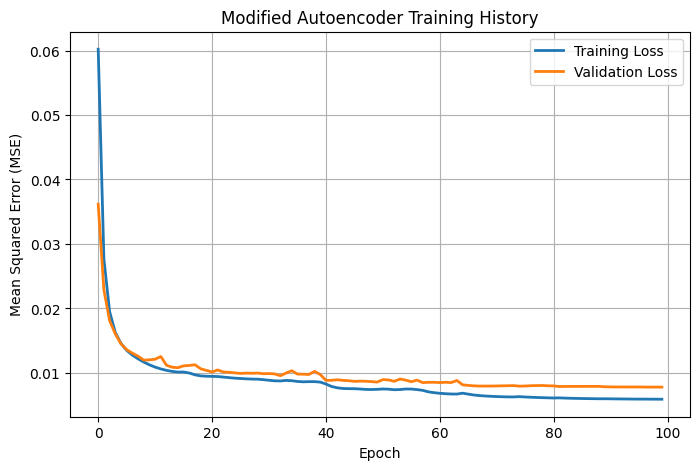

In [ ]:
plot_training_history(history_modified, "Modified Autoencoder")

### Modified Reconstruction Results

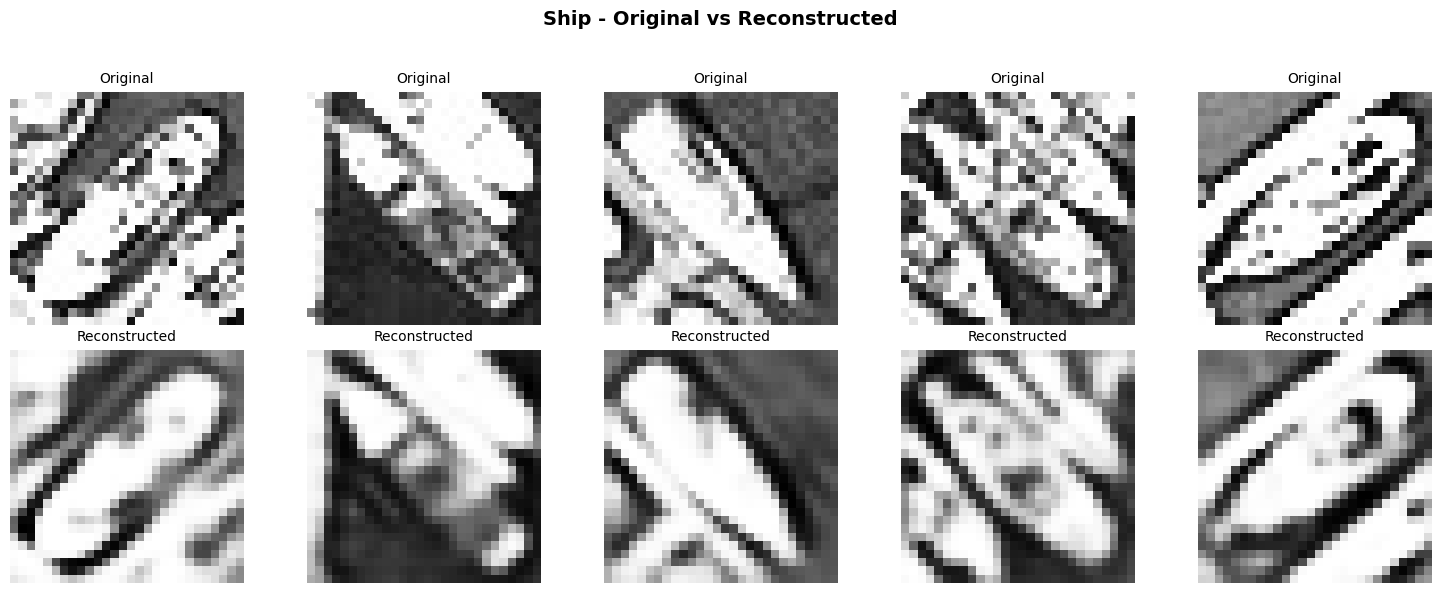

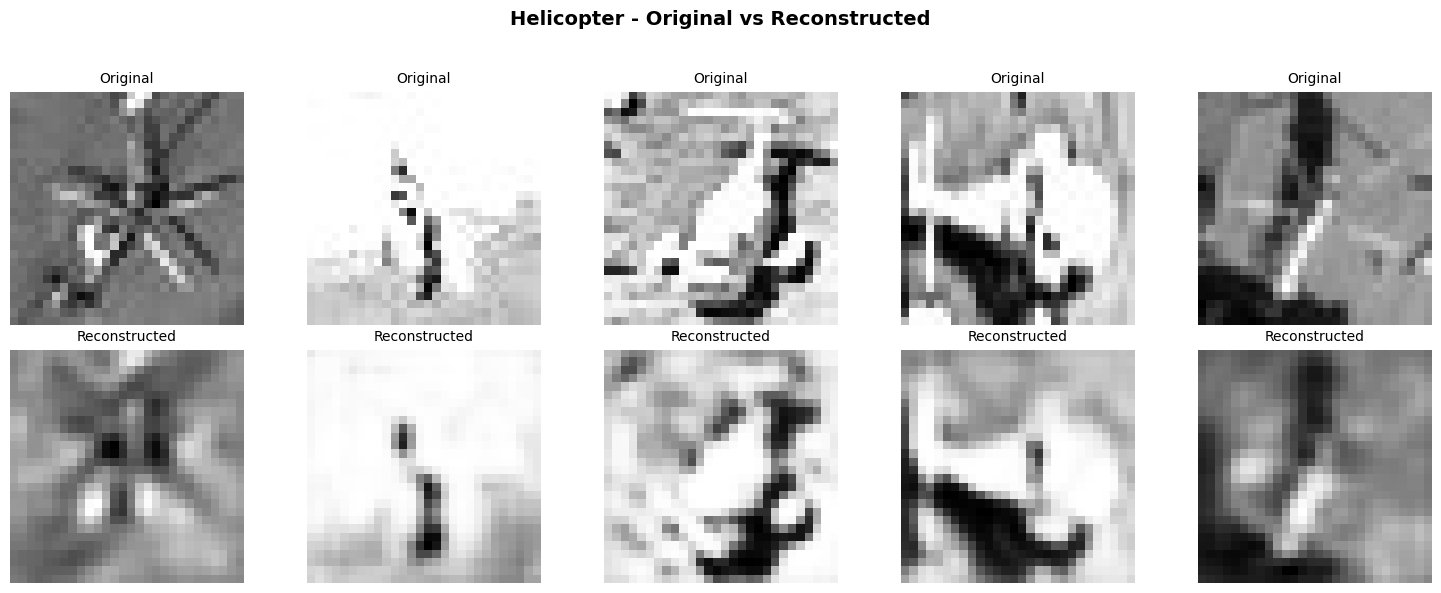

In [ ]:
visualize_reconstruction(modified_ae, x_test, y_test, class_name="ship")
visualize_reconstruction(modified_ae, x_test, y_test, class_name="helicopter")

### SSIM Evaluation

In [ ]:
modified_ssim, modified_scores = evaluate_ssim(modified_ae, x_test)

SSIM Evaluation
----------------------------------------
Mean SSIM : 0.7311
Min SSIM  : 0.3511
Max SSIM  : 0.9863
Std SSIM  : 0.1006


Berdasarkan hasil evaluasi, Modified Autoencoder memperoleh Mean SSIM sebesar 0.7311, yang menunjukkan bahwa **model mampu merekonstruksi citra dengan tingkat kemiripan struktur yang baik** terhadap citra asli. Nilai Max SSIM sebesar 0.9863 menunjukkan bahwa beberapa citra berhasil direkonstruksi hampir identik dengan citra asli, sedangkan Min SSIM sebesar 0.3511 mengindikasikan masih terdapat beberapa sampel yang lebih sulit direkonstruksi. Selain itu, Std SSIM sebesar 0.1006 menunjukkan bahwa kualitas rekonstruksi model cukup konsisten pada data uji. Hasil tersebut menunjukkan bahwa modifikasi arsitektur dengan **Batch Normalization, L2 Regularization, Conv2DTranspose sebagai learned upsampling, serta hyperparameter tuning menggunakan Huber Loss, learning rate 3×10⁻⁴, batch size 32, ReduceLROnPlateau, dan Early Stopping** mampu menghasilkan representasi fitur yang lebih informatif sehingga proses rekonstruksi citra menjadi lebih optimal.

## Baseline VS Modified

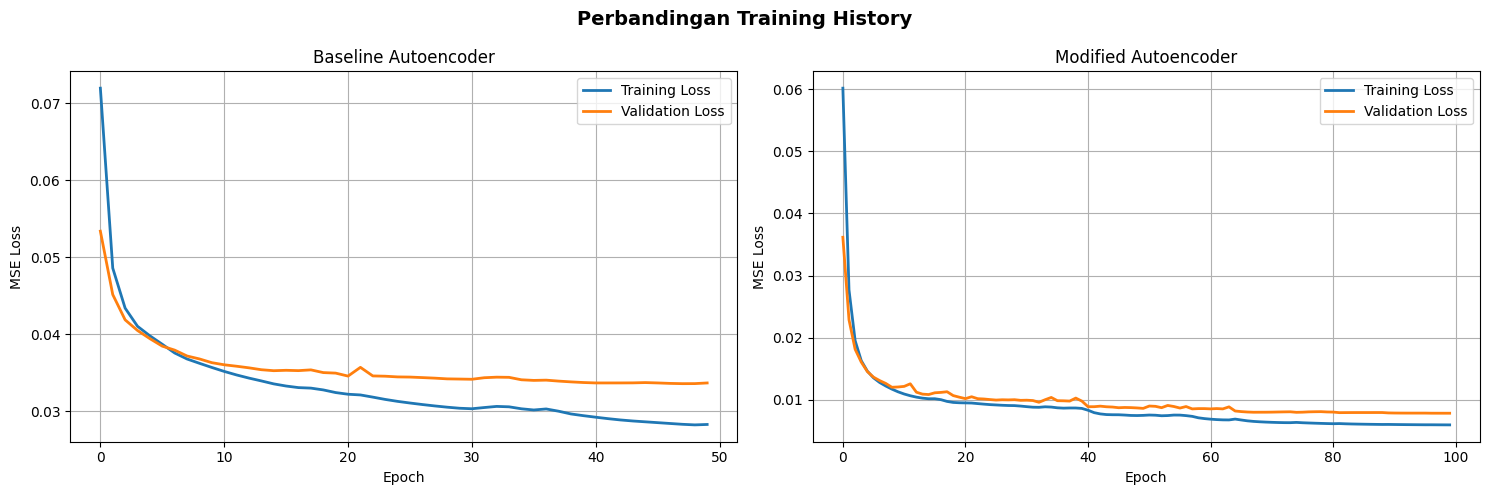

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Perbandingan Training History", fontsize=14, fontweight="bold")

axes[0].plot(history_baseline.history["loss"], label="Training Loss", linewidth=2)
axes[0].plot(history_baseline.history["val_loss"], label="Validation Loss", linewidth=2)
axes[0].set_title("Baseline Autoencoder", fontsize=12)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_modified.history["loss"], label="Training Loss", linewidth=2)
axes[1].plot(history_modified.history["val_loss"], label="Validation Loss", linewidth=2)
axes[1].set_title("Modified Autoencoder", fontsize=12)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
def compare_reconstruction(baseline_model, modified_model, x_test, y_test, class_name=None, n_images=5):
    baseline_reconstructed = baseline_model.predict(x_test, verbose=0)
    modified_reconstructed = modified_model.predict(x_test, verbose=0)

    idx_list = np.where(y_test == class_name)[0][:n_images]

    fig, axes = plt.subplots(3, n_images, figsize=(15, 8))

    fig.suptitle(f"{class_name.capitalize()} - Baseline vs Modified Reconstruction", fontsize=14, fontweight="bold")

    for i, idx in enumerate(idx_list):
        axes[0, i].imshow(x_test[idx].squeeze(), cmap="gray")
        axes[0, i].set_title("Original", fontsize=10)
        axes[0, i].axis("off")

        axes[1, i].imshow(baseline_reconstructed[idx].squeeze(), cmap="gray")
        axes[1, i].set_title("Baseline", fontsize=10)
        axes[1, i].axis("off")

        axes[2, i].imshow(modified_reconstructed[idx].squeeze(), cmap="gray")
        axes[2, i].set_title("Modified", fontsize=10)
        axes[2, i].axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

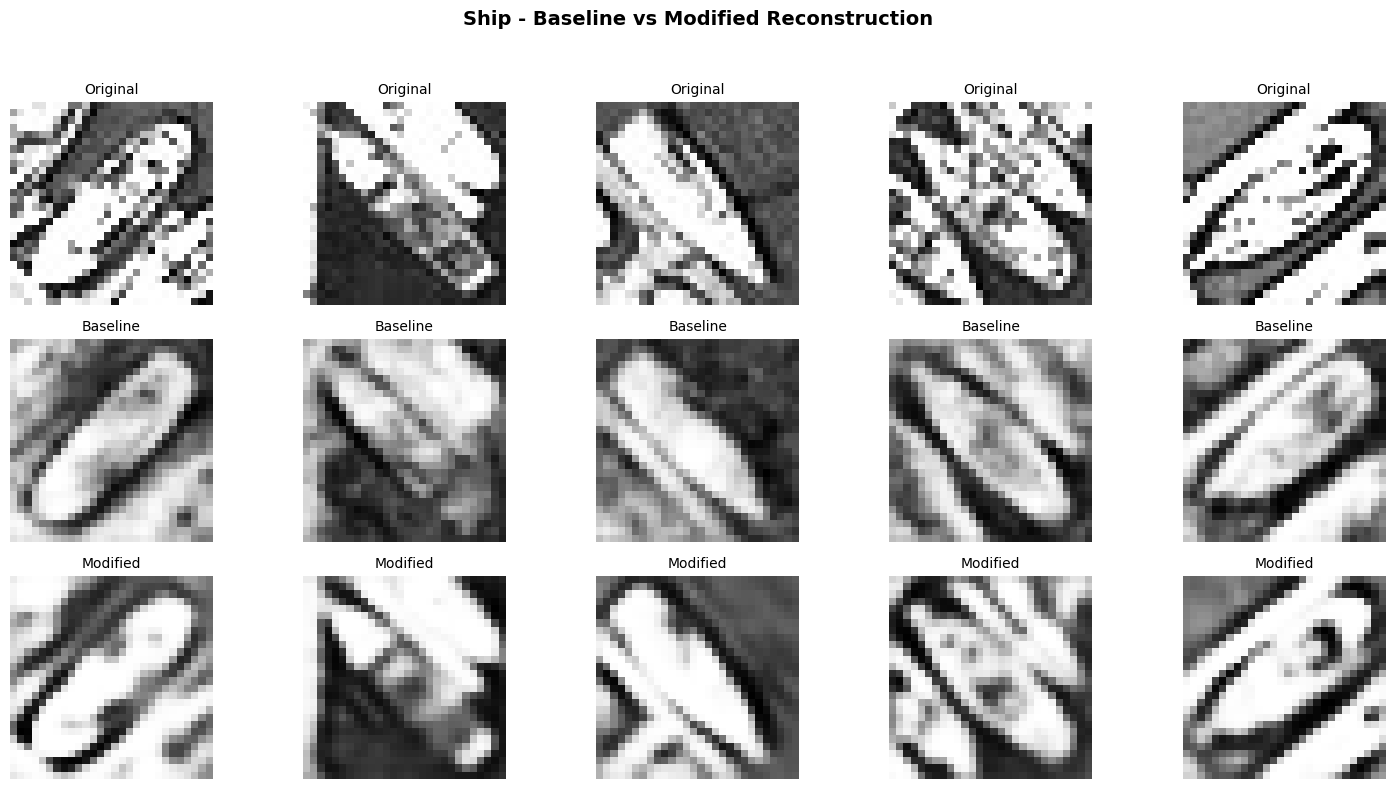

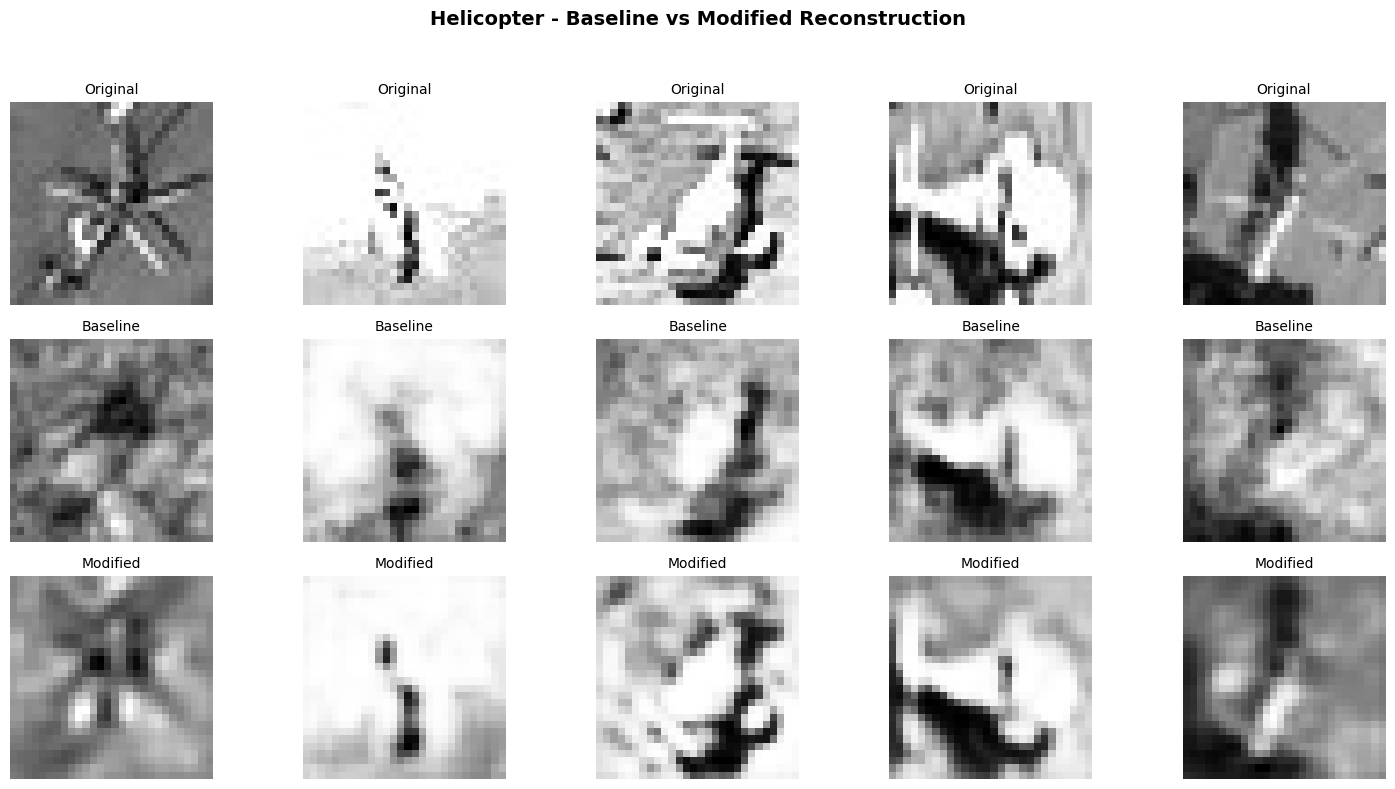

In [ ]:
compare_reconstruction(baseline_ae, modified_ae, x_test, y_test, class_name="ship")
compare_reconstruction(baseline_ae, modified_ae, x_test, y_test, class_name="helicopter")

In [ ]:
improvement = ((modified_ssim - baseline_ssim) / baseline_ssim) * 100

comparison_df = pd.DataFrame({"Model": ["Baseline Autoencoder", "Modified Autoencoder"],
                              "Mean SSIM": [baseline_ssim, modified_ssim],
                              "Min SSIM": [np.min(baseline_scores), np.min(modified_scores)],
                              "Max SSIM": [np.max(baseline_scores), np.max(modified_scores)],
                              "Std SSIM": [np.std(baseline_scores), np.std(modified_scores)],
                              "Improvement (%)": [np.nan, improvement]})
comparison_df

,Model,Mean SSIM,Min SSIM,Max SSIM,Std SSIM,Improvement (%)
0,Baseline Autoencoder,0.588287,0.134805,0.957124,0.137875,NaN
1,Modified Autoencoder,0.731139,0.351149,0.986330,0.100598,24.282788


Berdasarkan hasil perbandingan, **Modified Autoencoder menunjukkan performa yang lebih baik** dibandingkan Baseline Autoencoder. Grafik training history menunjukkan proses pelatihan yang lebih stabil dengan kurva training loss dan validation loss yang sama-sama konvergen. Selain itu, hasil visualisasi rekonstruksi memperlihatkan bahwa Modified Autoencoder mampu mempertahankan bentuk objek dan detail citra dengan lebih baik. Hal tersebut didukung oleh hasil evaluasi SSIM, di mana **Mean SSIM meningkat dari 0.5883 menjadi 0.7311 atau sekitar 24.28%**, Min SSIM meningkat dari 0.1348 menjadi 0.3511, Max SSIM meningkat dari 0.9571 menjadi 0.9863, serta Std SSIM menurun dari 0.1379 menjadi 0.1006, yang menunjukkan bahwa kualitas rekonstruksi menjadi lebih baik dan lebih konsisten pada seluruh data uji.